In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re

In [6]:
df = pd.read_excel('../data/raw/urban_pluvial_flood_risk_dataset.xlsx')
display(df.head())

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


In [7]:
print("Shape của dataset:", df.shape)
print("\nTên các cột:")
print(df.columns.tolist())
print("\n5 dòng đầu tiên:")
display(df.head())
print("\nThông tin tổng quát:")
print(df.info())

Shape của dataset: (2963, 17)

Tên các cột:
['segment_id', 'city_name', 'admin_ward', 'latitude', 'longitude', 'catchment_id', 'elevation_m', 'dem_source', 'land_use', 'soil_group', 'drainage_density_km_per_km2', 'storm_drain_proximity_m', 'storm_drain_type', 'rainfall_source', 'historical_rainfall_intensity_mm_hr', 'return_period_years', 'risk_labels']

5 dòng đầu tiên:


,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor



Thông tin tổng quát:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   object 
 1   city_name                            2963 non-null   object 
 2   admin_ward                           2963 non-null   object 
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   object 
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   object 
 8   land_use                             2963 non-null   object 
 9   soil_group                           2601 non-null   object 
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_dr

2. MISSING VALUES

                             missing_count  missing_percent
soil_group                             362            12.22
rainfall_source                        315            10.63
drainage_density_km_per_km2            284             9.58
storm_drain_proximity_m                239             8.07
storm_drain_type                       178             6.01
elevation_m                            161             5.43


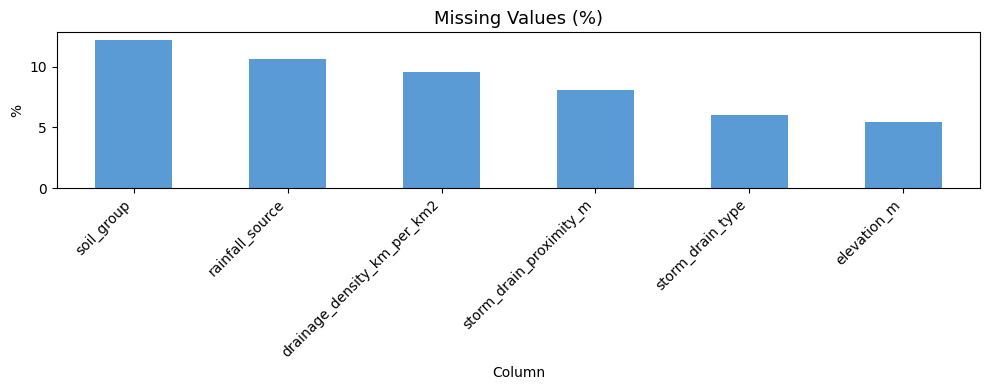

In [11]:
# ================================================================== #
# 2. MISSING VALUES
# ================================================================== #
print("=" * 60)
print("2. MISSING VALUES")
print("=" * 60)

missing = pd.DataFrame({
    'missing_count'  : df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_percent', ascending=False)

missing = missing[missing['missing_count'] > 0]

if missing.empty:
    print("\nKhông có missing values!")
else:
    print(f"\n{missing.to_string()}")

    # Visualize
    fig, ax = plt.subplots(figsize=(10, 4))
    missing['missing_percent'].plot(kind='bar', ax=ax, color='#5B9BD5')
    ax.set_title('Missing Values (%)', fontsize=13)
    ax.set_ylabel('%')
    ax.set_xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../experiments/figures/missing_values.png', dpi=150)
    plt.show()

3. PHÂN TÍCH TARGET

Raw risk_labels sample:
0                                       monitor
1    ponding_hotspot|low_lying|event_2025-05-02
2                                       monitor
3                                       monitor
4                                       monitor
5                          extreme_rain_history
6                                       monitor
7                                       monitor
8                    low_lying|event_2024-02-14
9                                       monitor

Tần suất từng label:
monitor                 1994
low_lying                666
extreme_rain_history     254
ponding_hotspot          222
sparse_drainage          181
Name: count, dtype: int64


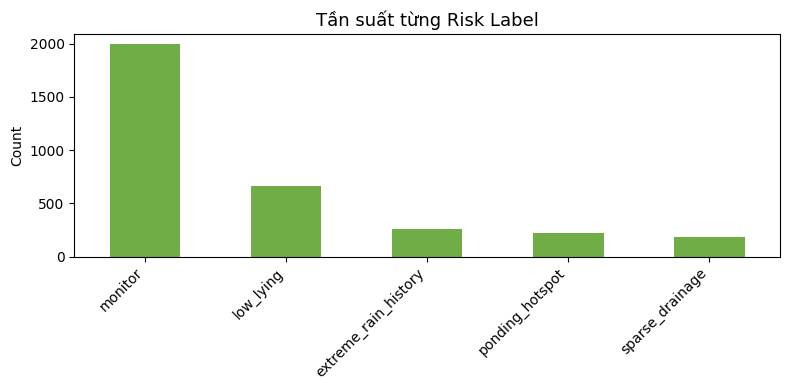


Phân bố sau khi chuyển sang 3 class:
            count  percent(%)
risk_class                   
Low          1994        67.3
Medium        574        19.4
High          395        13.3


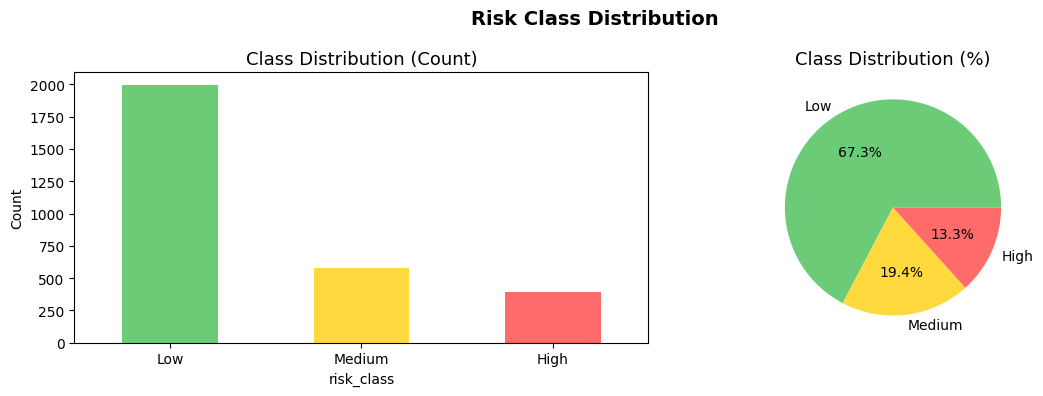


Imbalance ratio: 5.05x
→ Cần xử lý imbalance!


In [14]:
# ================================================================== #
# 3. PHÂN TÍCH TARGET — risk_labels → 3 class
# ================================================================== #
print("=" * 60)
print("3. PHÂN TÍCH TARGET")
print("=" * 60)

# 3.1 Xem raw labels trước
print("\nRaw risk_labels sample:")
print(df['risk_labels'].fillna('').head(10).to_string())

# 3.2 Đếm tần suất từng label
all_labels = []
for labels in df['risk_labels'].fillna(''):
    for label in labels.split('|'):
        label = label.strip()
        # Bỏ event dates (event_YYYY-MM-DD)
        if label and not re.match(r'event_\d{4}-\d{2}-\d{2}', label):
            all_labels.append(label)

label_counts = pd.Series(all_labels).value_counts()
print(f"\nTần suất từng label:\n{label_counts}")

fig, ax = plt.subplots(figsize=(8, 4))
label_counts.plot(kind='bar', ax=ax, color='#70AD47')
ax.set_title('Tần suất từng Risk Label', fontsize=13)
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../experiments/figures/label_frequency.png', dpi=150)
plt.show()

# 3.3 Chuyển sang 3 class theo priority rules
def assign_class(labels_str):
    if pd.isna(labels_str) or labels_str.strip() == '':
        return 'Low'
    labels = [l.strip() for l in labels_str.split('|')]
    # High: ponding_hotspot hoặc extreme_rain_history
    if any(l in ['ponding_hotspot', 'extreme_rain_history'] for l in labels):
        return 'High'
    # Medium: low_lying hoặc sparse_drainage
    if any(l in ['low_lying', 'sparse_drainage'] for l in labels):
        return 'Medium'
    # Low: chỉ có event date hoặc rỗng
    return 'Low'

df['risk_class'] = df['risk_labels'].apply(assign_class)

print(f"\nPhân bố sau khi chuyển sang 3 class:")
class_dist = df['risk_class'].value_counts()
class_pct  = df['risk_class'].value_counts(normalize=True).round(3) * 100
class_df   = pd.DataFrame({'count': class_dist, 'percent(%)': class_pct})
print(class_df)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = {'High': '#FF6B6B', 'Medium': '#FFD93D', 'Low': '#6BCB77'}
class_dist.plot(kind='bar', ax=axes[0],
                color=[colors[c] for c in class_dist.index])
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(class_dist, labels=class_dist.index, autopct='%1.1f%%',
            colors=[colors[c] for c in class_dist.index])
axes[1].set_title('Class Distribution (%)', fontsize=13)

plt.suptitle('Risk Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/figures/class_distribution.png', dpi=150)
plt.show()

# Imbalance ratio
max_class = class_dist.max()
min_class = class_dist.min()
print(f"\nImbalance ratio: {max_class/min_class:.2f}x")
print("→ Cần xử lý imbalance!" if max_class/min_class > 3 else "→ Tương đối balanced")

4. PHÂN BỐ NUMERIC FEATURES

Describe:
       elevation_m  drainage_density_km_per_km2  storm_drain_proximity_m  historical_rainfall_intensity_mm_hr  return_period_years
count      2802.00                      2679.00                  2724.00                              2963.00              2963.00
mean         37.69                         6.29                   123.20                                43.81                19.73
std          38.71                         2.19                   107.76                                25.22                25.18
min          -3.00                         1.27                     0.20                                 5.40                 2.00
25%           8.73                         4.67                    47.98                                25.80                 5.00
50%          25.13                         6.25                    91.70                                37.90                10.00
75%          59.62                         7

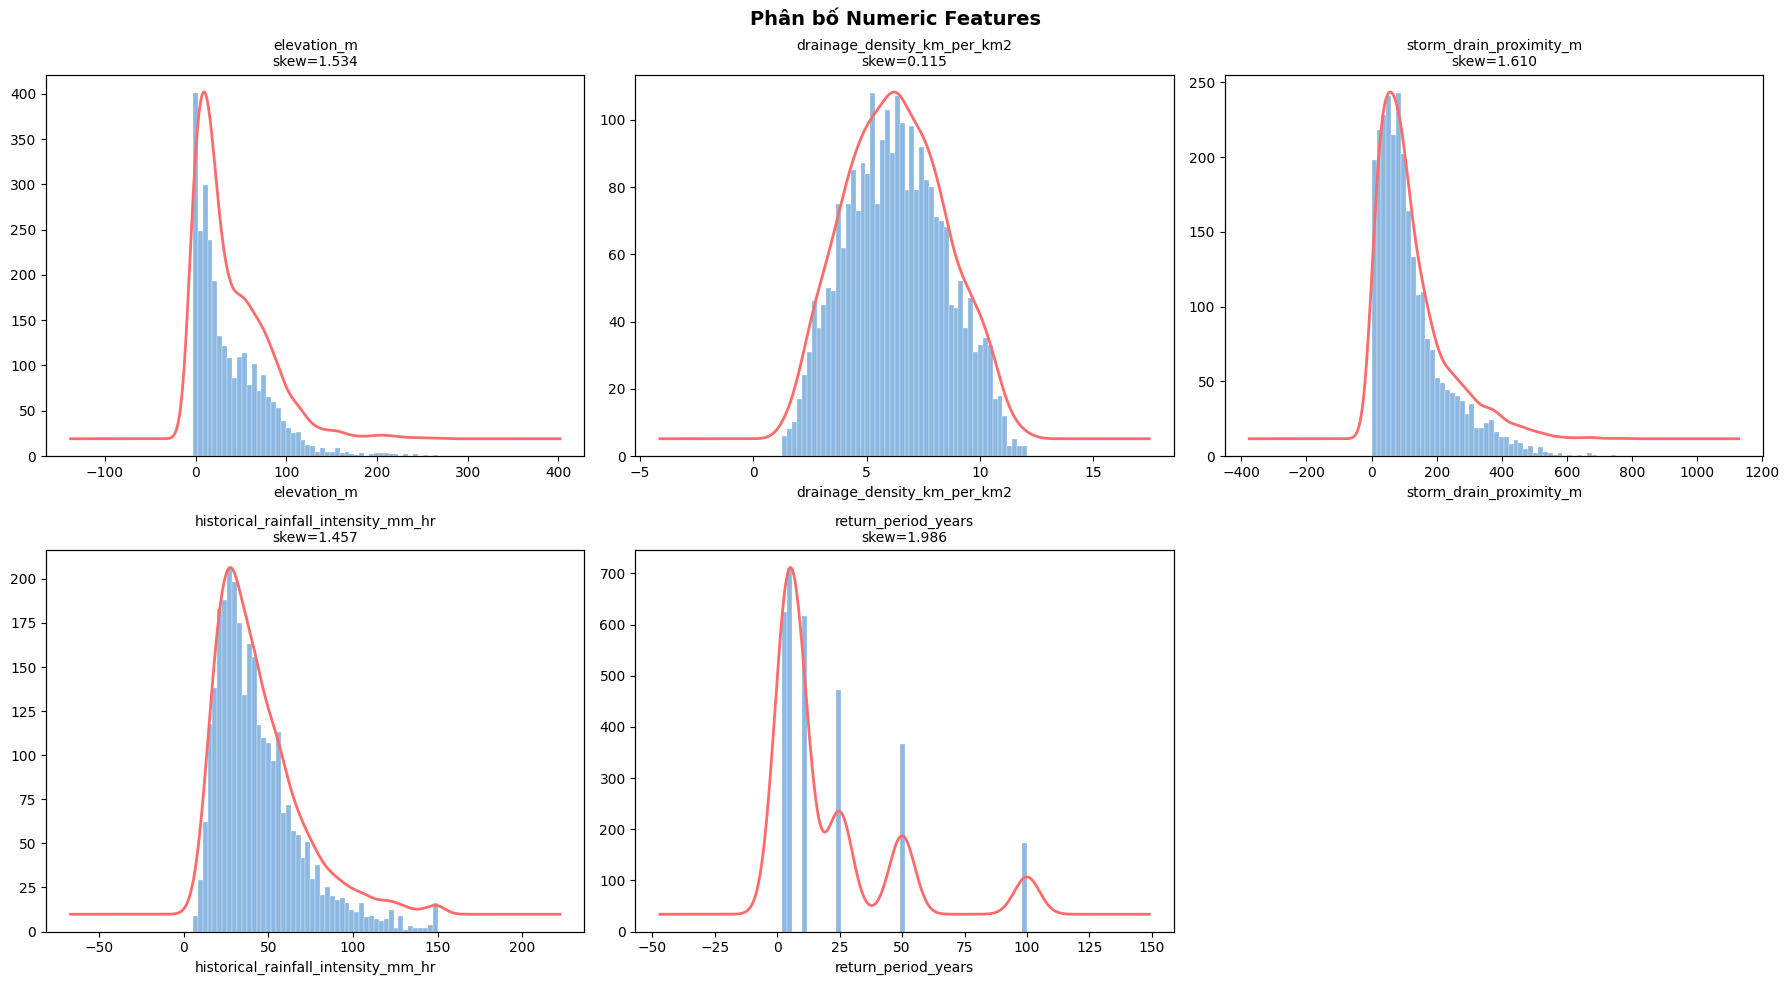

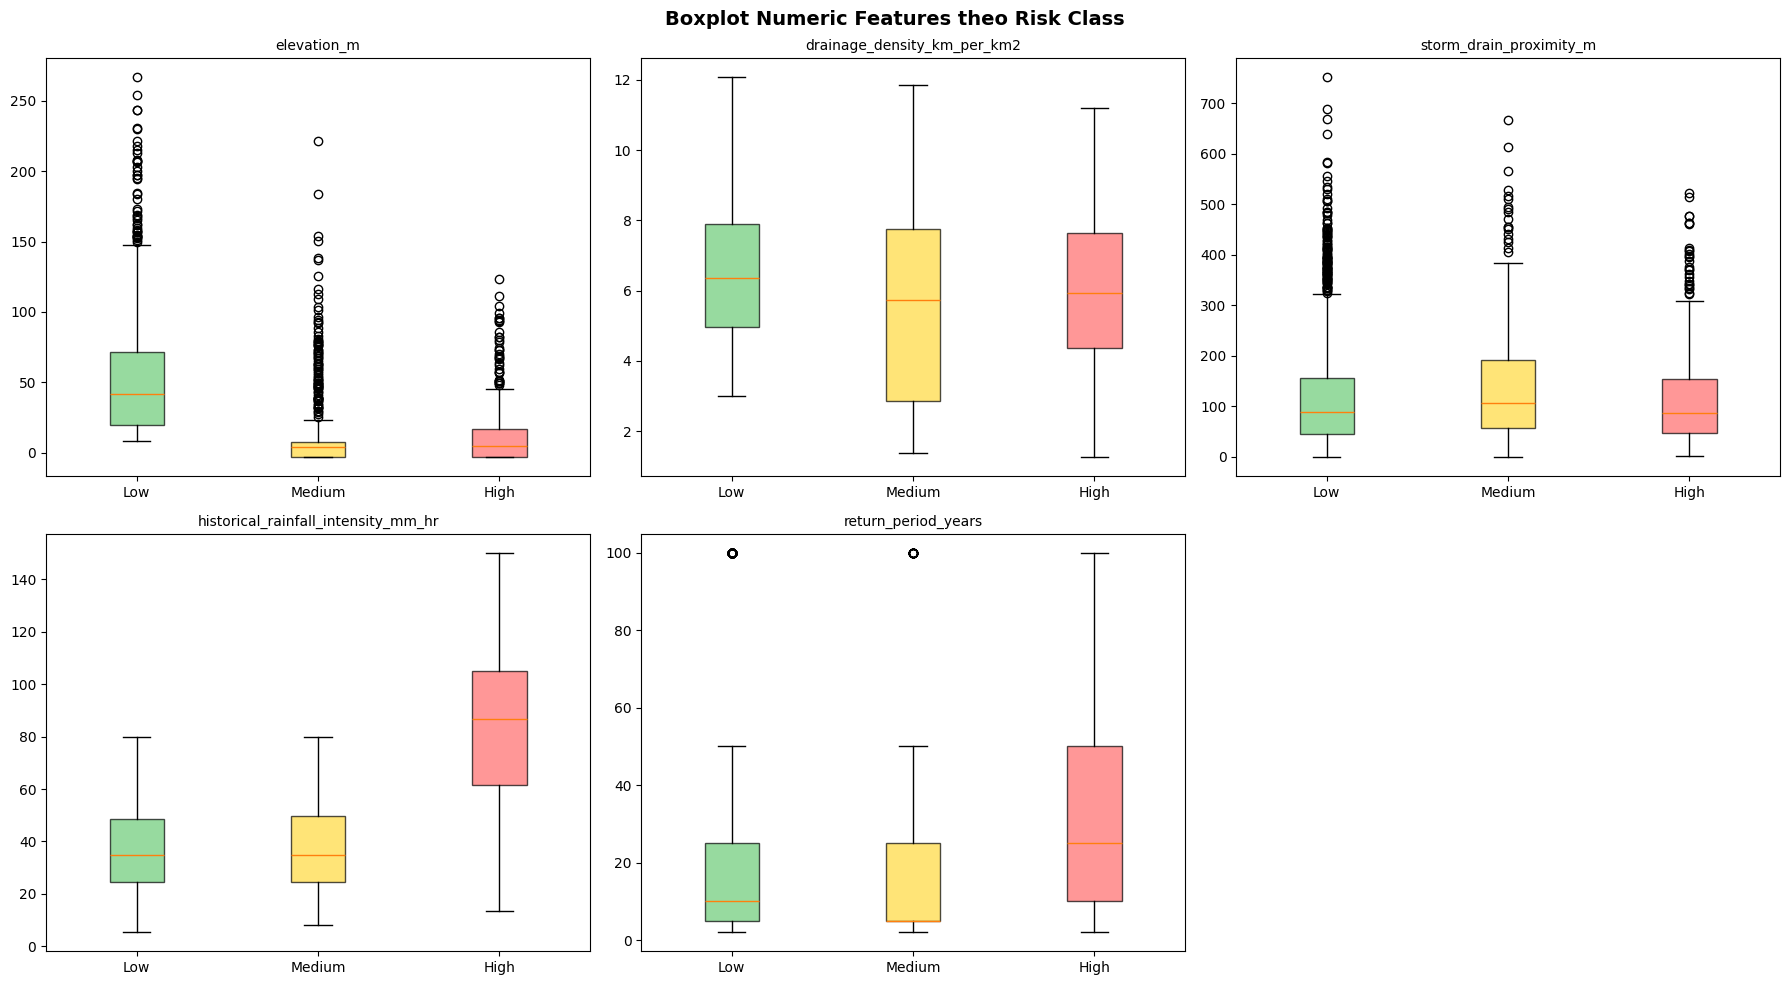

In [15]:
# ================================================================== #
# 4. PHÂN BỐ NUMERIC FEATURES
# ================================================================== #
print("=" * 60)
print("4. PHÂN BỐ NUMERIC FEATURES")
print("=" * 60)

numeric_cols = [
    'elevation_m',
    'drainage_density_km_per_km2',
    'storm_drain_proximity_m',
    'historical_rainfall_intensity_mm_hr',
    'return_period_years'
]

# 4.1 Thống kê mô tả
print("\nDescribe:")
print(df[numeric_cols].describe().round(2).to_string())

# 4.2 Skewness
print("\nSkewness:")
for col in numeric_cols:
    skew = df[col].skew()
    flag = '🔴 nặng' if abs(skew) > 1 else ('🟡 vừa' if abs(skew) > 0.5 else '🟢 ổn')
    print(f"  {col:45s}: {skew:7.3f} {flag}")

# 4.3 Histogram + KDE
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color='#5B9BD5', alpha=0.7,
            edgecolor='white', linewidth=0.3)
    ax2 = ax.twinx()
    data.plot.kde(ax=ax2, color='#FF6B6B', linewidth=2)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    skew = data.skew()
    ax.set_title(f'{col}\nskew={skew:.3f}', fontsize=10)
    ax.set_xlabel(col)

# Ẩn subplot thừa
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân bố Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/figures/numeric_distribution.png', dpi=150)
plt.show()

# 4.4 Boxplot theo class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    order = ['Low', 'Medium', 'High']
    colors_list = ['#6BCB77', '#FFD93D', '#FF6B6B']

    data_by_class = [df[df['risk_class'] == c][col].dropna() for c in order]
    bp = ax.boxplot(data_by_class, patch_artist=True, labels=order)
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Numeric Features theo Risk Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/figures/boxplot_by_class.png', dpi=150)
plt.show()

5. PHÂN TÍCH CATEGORICAL FEATURES

land_use: 9 unique values, 0 missing
  Values: {'Residential': 827, 'Roads': 599, 'Commercial': 493, 'Green': 359, 'Industrial': 357, 'Mixed': 110, 'Institutional': 106, 'Water': 83, 'Informal': 29}

soil_group: 4 unique values, 362 missing
  Values: {'B': 747, 'C': 713, 'D': 594, 'A': 547}

storm_drain_type: 4 unique values, 178 missing
  Values: {'CurbInlet': 843, 'Manhole': 749, 'GratedInlet': 644, 'OpenChannel': 549}

rainfall_source: 4 unique values, 315 missing
  Values: {'ERA5': 1334, 'LocalGauge': 502, 'Blended': 445, 'IMD': 367}

dem_source: 5 unique values, 0 missing
  Values: {'Copernicus_GLO-30_v2023': 869, 'SRTM_1arc': 783, 'SRTM_3arc': 550, 'Copernicus_EEA-10_v5': 500, 'Copernicus_GLO-90_v2022': 261}


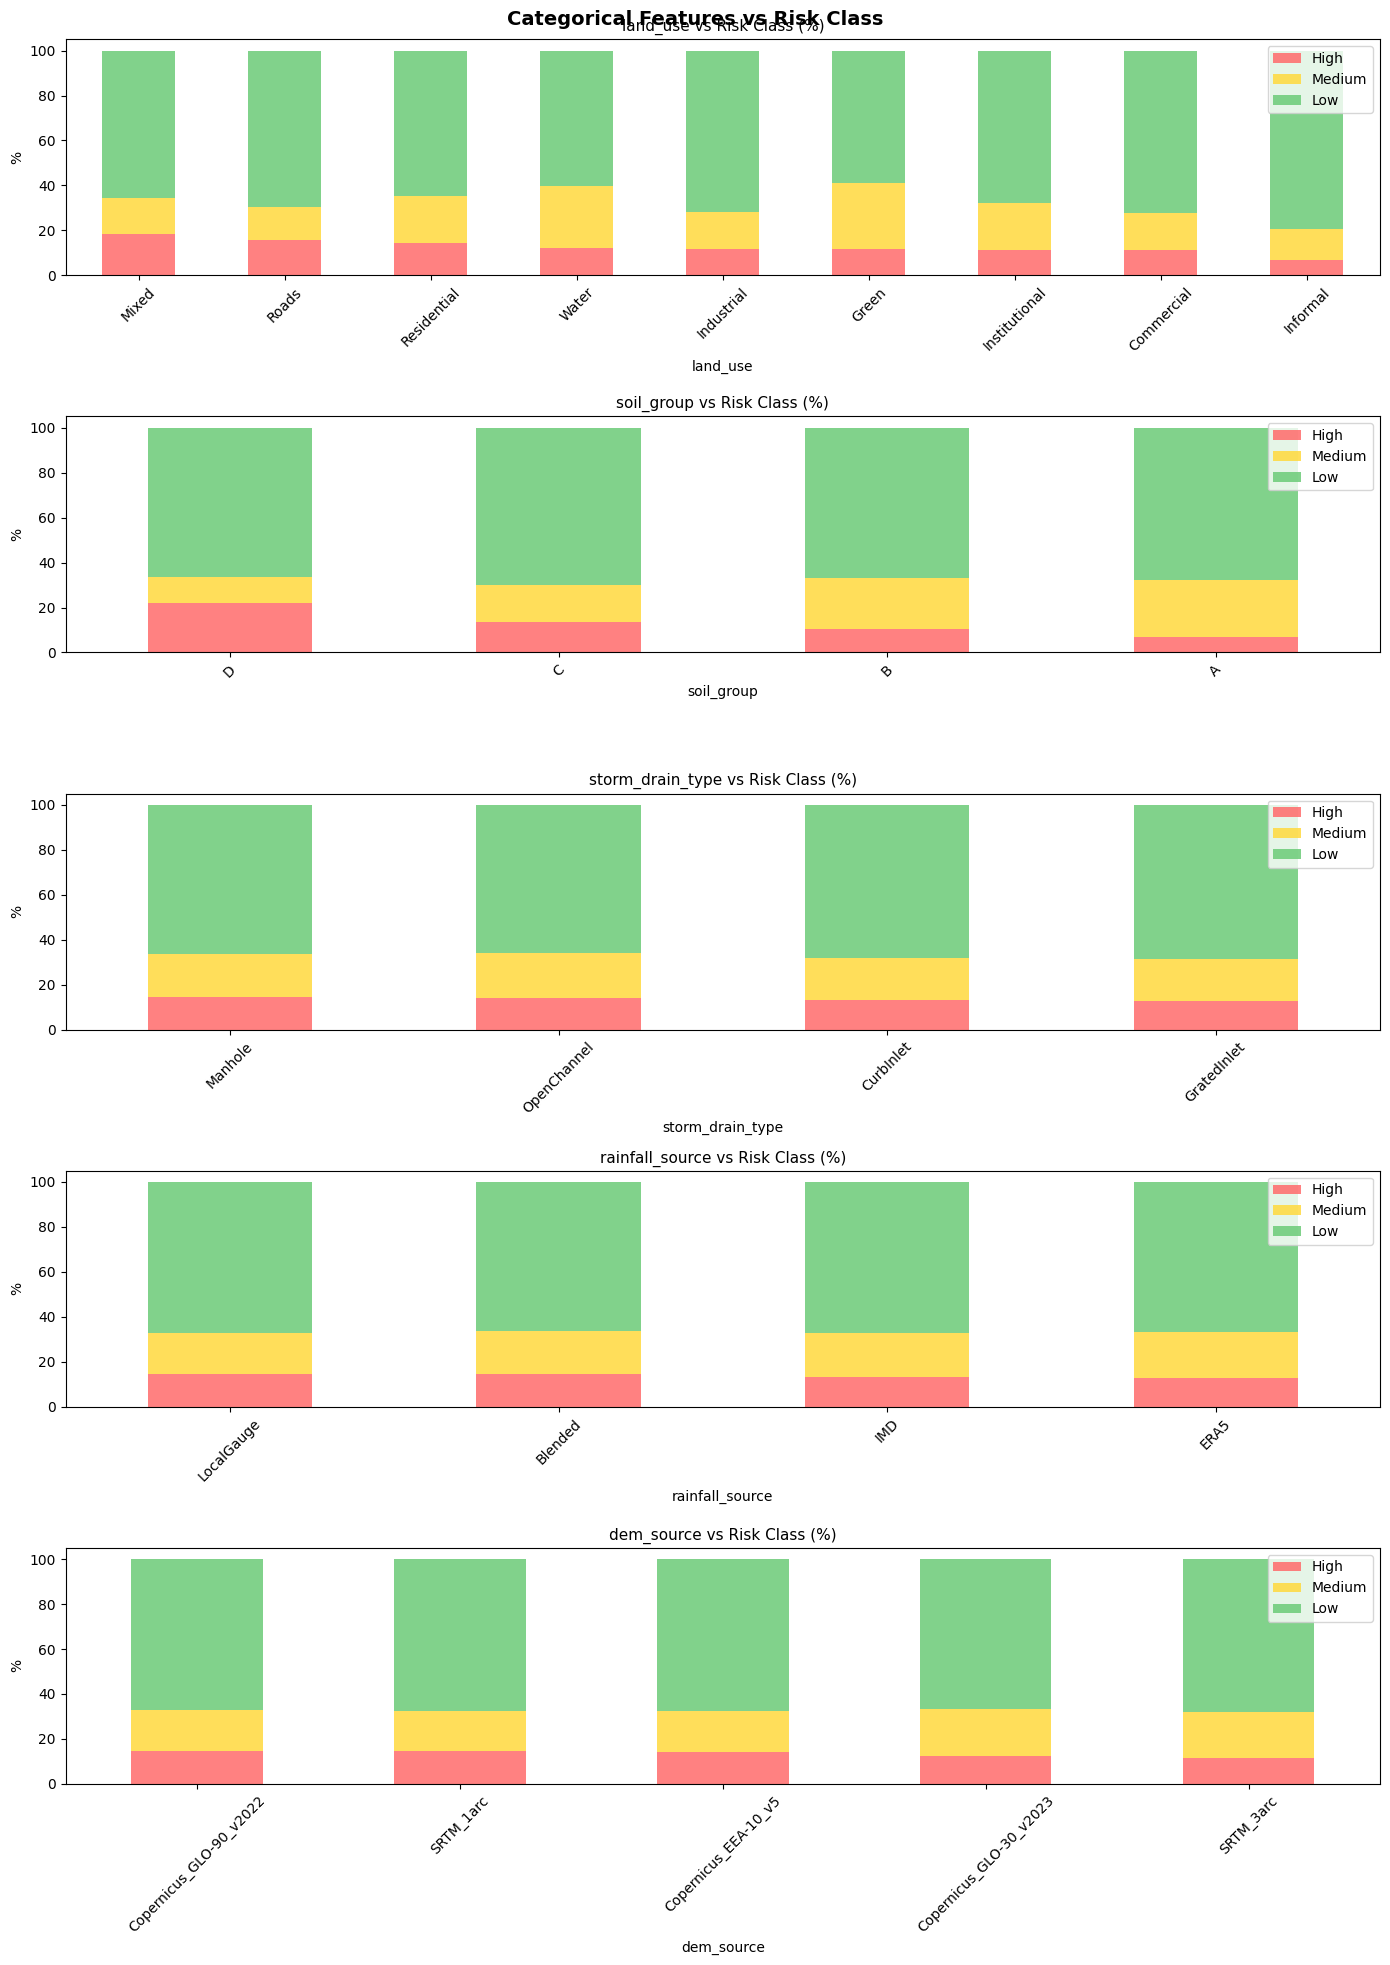

In [17]:
# ================================================================== #
# 5. PHÂN TÍCH CATEGORICAL FEATURES
# ================================================================== #
print("=" * 60)
print("5. PHÂN TÍCH CATEGORICAL FEATURES")
print("=" * 60)

categorical_cols = [
    'land_use', 'soil_group',
    'storm_drain_type', 'rainfall_source', 'dem_source'
]

# 5.1 Số unique values và missing
for col in categorical_cols:
    n_unique  = df[col].nunique()
    n_missing = df[col].isnull().sum()
    print(f"\n{col}: {n_unique} unique values, {n_missing} missing")
    print(f"  Values: {df[col].value_counts().to_dict()}")

# 5.2 Stacked bar: phân bố class theo từng categorical feature
fig, axes = plt.subplots(len(categorical_cols), 1,
                         figsize=(14, len(categorical_cols) * 4))

for ax, col in zip(axes, categorical_cols):
    ct = pd.crosstab(df[col], df['risk_class'], normalize='index') * 100
    # Sắp xếp theo tỷ lệ High
    if 'High' in ct.columns:
        ct = ct.sort_values('High', ascending=False)

    ct[['High', 'Medium', 'Low']].plot(
        kind='bar', stacked=True, ax=ax,
        color=['#FF6B6B', '#FFD93D', '#6BCB77'],
        alpha=0.85
    )
    ax.set_title(f'{col} vs Risk Class (%)', fontsize=11)
    ax.set_ylabel('%')
    ax.set_xlabel(col)
    ax.legend(loc='upper right')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Risk Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/figures/categorical_vs_class.png', dpi=150)
plt.show()

6. CORRELATION MATRIX


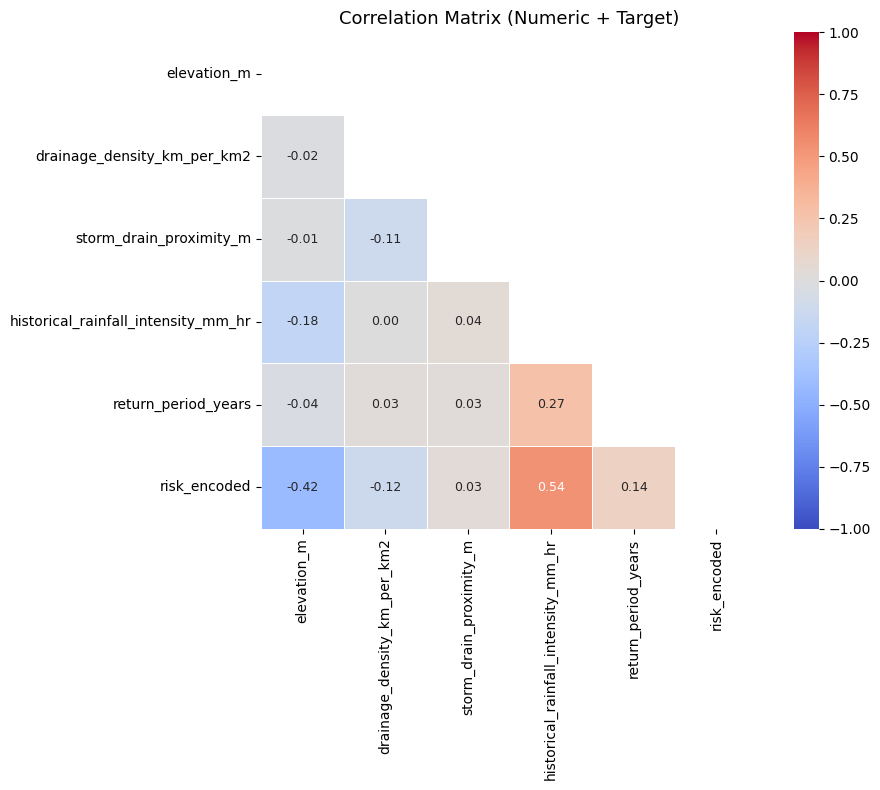


Correlation với risk_encoded:
  historical_rainfall_intensity_mm_hr          :   0.536 ⭐
  elevation_m                                  :  -0.424 ⭐
  return_period_years                          :   0.137 
  drainage_density_km_per_km2                  :  -0.120 
  storm_drain_proximity_m                      :   0.032 


In [18]:
# ================================================================== #
# 6. CORRELATION MATRIX
# ================================================================== #
print("=" * 60)
print("6. CORRELATION MATRIX")
print("=" * 60)

# Encode target và categorical tạm thời để tính correlation
df_corr = df[numeric_cols].copy()
df_corr['risk_encoded'] = df['risk_class'].map({'Low': 0, 'Medium': 1, 'High': 2})

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix (Numeric + Target)', fontsize=13)
plt.tight_layout()
plt.savefig('../experiments/figures/correlation_matrix.png', dpi=150)
plt.show()

# Correlation với target
print("\nCorrelation với risk_encoded:")
target_corr = corr['risk_encoded'].drop('risk_encoded').sort_values(key=abs, ascending=False)
for col, val in target_corr.items():
    flag = '⭐' if abs(val) > 0.3 else ''
    print(f"  {col:45s}: {val:7.3f} {flag}")

In [20]:
# 1. Missing theo risk_class
missing_cols = ['soil_group', 'rainfall_source', 'drainage_density_km_per_km2', 
                'storm_drain_proximity_m', 'storm_drain_type', 'elevation_m']

print("=" * 60)
print("MISSING RATE THEO RISK CLASS")
print("=" * 60)
for col in missing_cols:
    print(f"\n{col}:")
    print(df.groupby('risk_class')[col].apply(lambda x: f"{x.isna().mean():.1%} missing"))

# 2. Missing theo city
print("\n" + "=" * 60)
print("MISSING RATE THEO CITY (top problematic)")
print("=" * 60)
for col in missing_cols:
    city_missing = df.groupby('city_name')[col].apply(lambda x: x.isna().mean())
    problematic = city_missing[city_missing > 0.2]
    if len(problematic) > 0:
        print(f"\n{col} — cities có >20% missing:")
        print(problematic.sort_values(ascending=False))

MISSING RATE THEO RISK CLASS

soil_group:
risk_class
High      13.2% missing
Low       11.5% missing
Medium    14.1% missing
Name: soil_group, dtype: object

rainfall_source:
risk_class
High       8.6% missing
Low       11.4% missing
Medium     9.4% missing
Name: rainfall_source, dtype: object

drainage_density_km_per_km2:
risk_class
High       9.1% missing
Low       10.0% missing
Medium     8.5% missing
Name: drainage_density_km_per_km2, dtype: object

storm_drain_proximity_m:
risk_class
High      7.8% missing
Low       7.7% missing
Medium    9.6% missing
Name: storm_drain_proximity_m, dtype: object

storm_drain_type:
risk_class
High      4.1% missing
Low       6.0% missing
Medium    7.3% missing
Name: storm_drain_type, dtype: object

elevation_m:
risk_class
High      4.6% missing
Low       6.9% missing
Medium    1.0% missing
Name: elevation_m, dtype: object

MISSING RATE THEO CITY (top problematic)

soil_group — cities có >20% missing:
city_name
Mexico City, Mexico    0.210526
Shenzh

In [21]:
print("=" * 60)
print("OUTLIER ANALYSIS (IQR method)")
print("=" * 60)

numeric_cols = ['elevation_m', 'drainage_density_km_per_km2', 
                'storm_drain_proximity_m', 'historical_rainfall_intensity_mm_hr',
                'return_period_years']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}:")
    print(f"  Range hợp lệ: [{lower:.2f}, {upper:.2f}]")
    print(f"  Số outlier  : {len(outliers)} ({len(outliers)/len(df):.1%})")
    print(f"  Risk class của outliers:")
    print(f"  {outliers['risk_class'].value_counts().to_dict()}")

OUTLIER ANALYSIS (IQR method)

elevation_m:
  Range hợp lệ: [-67.62, 135.96]
  Số outlier  : 63 (2.1%)
  Risk class của outliers:
  {'Low': 57, 'Medium': 6}

drainage_density_km_per_km2:
  Range hợp lệ: [-0.07, 12.57]
  Số outlier  : 0 (0.0%)
  Risk class của outliers:
  {}

storm_drain_proximity_m:
  Range hợp lệ: [-124.00, 334.60]
  Số outlier  : 163 (5.5%)
  Risk class của outliers:
  {'Low': 101, 'Medium': 39, 'High': 23}

historical_rainfall_intensity_mm_hr:
  Range hợp lệ: [-18.82, 100.17]
  Số outlier  : 120 (4.0%)
  Risk class của outliers:
  {'High': 120}

return_period_years:
  Range hợp lệ: [-25.00, 55.00]
  Số outlier  : 174 (5.9%)
  Risk class của outliers:
  {'Low': 105, 'High': 48, 'Medium': 21}


In [22]:
print("=" * 60)
print("INTERACTION: elevation x rainfall theo risk_class")
print("=" * 60)

# Tạo interaction
df['rain_x_return'] = df['historical_rainfall_intensity_mm_hr'] * df['return_period_years']
df['elev_bin'] = pd.cut(df['elevation_m'], bins=[-np.inf, 5, 20, 50, np.inf], 
                         labels=['very_low', 'low', 'mid', 'high'])

print("\nrain_x_return theo risk_class:")
print(df.groupby('risk_class')['rain_x_return'].describe()[['mean','std','min','max']])

print("\nDistribution elev_bin theo risk_class (%):")
print(df.groupby('risk_class')['elev_bin'].value_counts(normalize=True).mul(100).round(1).unstack())

# Correlation của interaction với target
from scipy.stats import spearmanr
target_encoded = df['risk_class'].map({'Low': 0, 'Medium': 1, 'High': 2})
corr, pval = spearmanr(df['rain_x_return'].fillna(0), target_encoded)
print(f"\nSpearman corr(rain_x_return, target): {corr:.3f} (p={pval:.4f})")

elev_corr, elev_pval = spearmanr(df['elevation_m'].fillna(df['elevation_m'].median()), target_encoded)
print(f"Spearman corr(elevation_m, target)  : {elev_corr:.3f} (p={elev_pval:.4f})")

INTERACTION: elevation x rainfall theo risk_class

rain_x_return theo risk_class:
                   mean          std   min      max
risk_class                                         
High        3039.992911  3412.297474  30.0  15000.0
Low          744.692778  1160.240283  13.2   7770.0
Medium       655.683798  1059.606057  17.2   7210.0

Distribution elev_bin theo risk_class (%):
elev_bin    very_low   low   mid  high
risk_class                            
High            50.7  29.4  11.4   8.5
Low              0.0  25.3  31.7  43.0
Medium          55.3  28.7   6.7   9.3

Spearman corr(rain_x_return, target): 0.214 (p=0.0000)
Spearman corr(elevation_m, target)  : -0.589 (p=0.0000)


# 📊 Tổng Hợp EDA — Urban Flood Risk Dataset

> **Dataset:** 2963 segments × 17 cột | **Task:** Multiclass classification (Low / Medium / High risk)

---

## 1. Tổng Quan Dataset

| Thuộc tính | Chi tiết |
|---|---|
| Số mẫu | 2963 |
| Số features | 16 (sau khi bỏ `segment_id`) |
| Target | `risk_class` (Low / Medium / High) — chuyển từ `risk_labels` |
| Numeric features | 5 |
| Categorical features | 7 (bao gồm ID và metadata) |

---

## 2. Phân Bố Target (Class Imbalance)

| Class | Số mẫu | Tỷ lệ |
|---|---|---|
| Low | 1994 | 67.3% |
| Medium | 574 | 19.4% |
| High | 395 | 13.3% |

> ⚠️ **Imbalance ratio: 5.05x** — Class High chiếm rất ít. Cần xử lý khi train model (dùng `class_weight='balanced'`).

---

## 3. Missing Values

| Feature | Missing | Tỷ lệ | Pattern |
|---|---|---|---|
| `soil_group` | 362 | 12.2% | Đều giữa các class (~11–14%) |
| `rainfall_source` | 315 | 10.6% | Đều giữa các class (~9–11%) |
| `drainage_density_km_per_km2` | 284 | 9.6% | Đều giữa các class (~9–10%) |
| `storm_drain_proximity_m` | 239 | 8.1% | Đều giữa các class (~8–10%) |
| `storm_drain_type` | 178 | 6.0% | Đều giữa các class (~4–7%) |
| `elevation_m` | 161 | 5.4% | Đều giữa các class (~1–7%) |

> ✅ **Kết luận: Missing hoàn toàn ngẫu nhiên (MCAR)** — tỷ lệ missing không có pattern theo class. Missing tập trung theo city (data collection issue), không liên quan đến risk level.
>
> → **Chiến lược:** Median impute cho numeric. Thêm category `"Unknown"` cho categorical (không dùng mode impute vì missing theo city có thể mang thông tin).

---

## 4. Phân Tích Numeric Features

### 4.1 Thống Kê Cơ Bản

| Feature | Mean | Std | Min | Max | Skew |
|---|---|---|---|---|---|
| `elevation_m` | 37.7 | 38.7 | -3.0 | 266.7 | 1.53 🔴 |
| `drainage_density_km_per_km2` | 6.29 | 2.19 | 1.27 | 12.07 | 0.12 ✅ |
| `storm_drain_proximity_m` | 123.2 | 107.8 | 0.2 | 751.7 | 1.61 🔴 |
| `historical_rainfall_intensity_mm_hr` | 43.8 | 25.2 | 5.4 | 150.0 | 1.46 🔴 |
| `return_period_years` | 19.7 | 25.2 | 2.0 | 100.0 | 1.99 🔴 |

> 🔴 Skew nặng (>1.0): cần **Yeo-Johnson** nếu dùng Linear models / SVM / KNN.
> ✅ Tree-based models (RF, XGBoost, LightGBM) **không cần transform**.

### 4.2 Correlation Với Target

| Feature | Pearson | Spearman | Ghi chú |
|---|---|---|---|
| `elevation_m` | -0.42 | **-0.589** | Feature quan trọng nhất |
| `historical_rainfall_intensity_mm_hr` | +0.54 | — | Feature quan trọng thứ hai |
| `return_period_years` | +0.14 | — | Ảnh hưởng yếu |
| `drainage_density_km_per_km2` | -0.02 | — | Gần như không tương quan |
| `storm_drain_proximity_m` | -0.12 | — | Tương quan yếu |

> 💡 Spearman của `elevation_m` (-0.589) cao hơn nhiều so với Pearson (-0.42) vì phân bố skewed — **đây là feature dự đoán tốt nhất trong dataset**.

---


## 5. Phân Tích Outliers

| Feature | Số outlier | Tỷ lệ | Class của outlier | Quyết định |
|---|---|---|---|---|
| `elevation_m` | 63 | 2.1% | Toàn **Low** | ✅ **Giữ nguyên** — vùng cao → đúng là Low risk |
| `storm_drain_proximity_m` | 163 | 5.5% | Mix đều các class | ⚠️ **Clip** tại 95th percentile |
| `historical_rainfall_intensity_mm_hr` | 120 | 4.0% | Toàn **High** | ✅ **Giữ nguyên tuyệt đối** — đây chính là signal của High risk |
| `return_period_years` | 174 | 5.9% | Mix đều | ✅ **Giữ nguyên** — giá trị discrete hợp lệ (2,5,10,25,50,100) |
| `drainage_density_km_per_km2` | 0 | 0% | — | Không có outlier |

> ⚠️ **Quan trọng:** Tuyệt đối **KHÔNG clip** `historical_rainfall_intensity_mm_hr` — 120 outlier này đều là High risk, clip sẽ làm mất signal quan trọng nhất của class cần dự đoán.

---

## 6. Insight Quan Trọng: Elevation + Rainfall

### Phân bố elevation theo class:

| Elevation | High risk | Medium risk | Low risk |
|---|---|---|---|
| Very low (<5m) | **50.7%** | **55.3%** | 0.0% |
| Low (5–20m) | 29.4% | 28.7% | 25.3% |
| Mid (20–50m) | 11.4% | 6.7% | 31.7% |
| High (>50m) | 8.5% | 9.3% | 43.0% |

> 🔑 **Key insight:** Low risk **không bao giờ** ở very_low elevation. High và Medium đều tập trung ở vùng thấp.

### Điều gì phân biệt High vs Medium (cùng elevation thấp)?

| Class | `rain_x_return` (mean) |
|---|---|
| High | **3040** |
| Medium | 656 |
| Low | 745 |

> → **High = vùng thấp + mưa lớn/return period dài**. Medium = vùng thấp nhưng mưa ít. Interaction feature `rain_x_return` capture được điều này.

---

## 7. Categorical Features

Từ biểu đồ phân bố, tất cả categorical features (`land_use`, `soil_group`, `storm_drain_type`, `rainfall_source`, `dem_source`) đều có **phân bố High/Medium/Low khá đồng đều** trong mỗi category → **predictive power thấp** so với numeric features.

> Tuy nhiên vẫn nên giữ lại vì tree-based models có thể khai thác interaction với numeric features.

---

## 8. Feature Engineering Đề Xuất

Dựa trên phân tích, thêm 2 features mới:

```python
# 1. Flag vùng rất thấp — phân biệt rõ Low risk vs High/Medium
df['is_very_low_elev'] = (df['elevation_m'] < 5).astype(int)

# 2. Interaction: cường độ mưa × return period
df['rain_x_return'] = (df['historical_rainfall_intensity_mm_hr']
                       * df['return_period_years'])
# Spearman corr với target: 0.214 (p < 0.0001)
```

---

## 9. Tổng Hợp Preprocessing Plan

```
CHUNG (áp dụng cho cả tree lẫn linear pipeline):
├── Impute numeric          → median
├── Impute categorical      → thêm category "Unknown"
├── elevation_m             → giữ outlier (valid data)
├── storm_drain_proximity_m → clip tại 95th percentile
├── rainfall_intensity      → KHÔNG clip (signal của High risk)
├── return_period_years     → giữ nguyên (discrete values)
└── Feature mới:
    ├── is_very_low_elev    (elevation < 5m → 0/1)
    └── rain_x_return       (intensity × return_period)

TREE pipeline (DT, RF, XGBoost, LightGBM):
└── Ordinal/Label encoding cho categorical

LINEAR pipeline (Logistic, SVM, KNN):
├── log1p transform: elevation_m, storm_drain_proximity_m,
│                   rainfall_intensity, return_period_years
├── StandardScaler  (bắt buộc)
└── One-hot encoding cho categorical
```

---

## 10. Lưu Ý Khi Train Model

| Vấn đề | Giải pháp |
|---|---|
| Class imbalance 5x | Dùng `class_weight='balanced'` cho tất cả model |
| Val set nhỏ (~444 mẫu) | Đánh giá bằng CV=10 thay vì fixed val set |
| Feature quan trọng nhất | `elevation_m` và `historical_rainfall_intensity_mm_hr` |
| Features ít hữu ích | `drainage_density`, `storm_drain_proximity` (corr < 0.15) |

---

*Tổng hợp bởi EDA pipeline — cập nhật sau khi có thêm phân tích*

*Ta đang có 2 pipeline*

TreePreProcess để dành cho các các thuật toán TreeBased

LinearPreProcess để dành cho các thuật toán cần sử dụng đến khoảng cách như LR, SVM, KNN

| Bước            | Pipeline A (Tree)        | Pipeline B (Linear/Distance) | Lý do khác nhau                              |
|-----------------|-------------------------|------------------------------|----------------------------------------------|
| Impute missing  | ✅ KNN Imputer          | ✅ KNN Imputer               | Cả 2 đều cần                                 |
| Clip outlier    | ✅ nhẹ (1%-99%)         | ✅ chặt hơn (5%-95%)         | Linear nhạy cảm hơn với outlier              |
| Fix skew        | ❌ không cần            | ✅ Yeo-Johnson               | Tree không quan tâm phân bố                 |
| Scale           | ❌ không cần            | ✅ RobustScaler              | Tree không dùng khoảng cách                 |
| Drop VIF        | ❌ không cần            | ✅ drop nếu VIF > 10         | Linear bị unstable với multicollinear       |
